# Platform Stabilogram

This file contains:
- extration of stabilogrma from force platform gait-line.csv
- stabilogram is synchronizatinized with begin time extracted from .xml
- stabilogram is centered
- CoP variables are extracted

At the end of the file, there is a comparison plot with radar stabilogram

In [145]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from code_descriptors_postural_control.stabilogram.stato import Stabilogram
from code_descriptors_postural_control.descriptors import compute_all_features

In [146]:
# xml_file = "../data/antoine/plateforme/test4.xml"
# csv_gait_file = "../data/antoine/plateforme/test4/gait-line.csv"


In [147]:
xml_file = "../data/kelly/plat.xml"
csv_gait_file = "../data/kelly/gait-line.csv"

In [148]:
import xml.etree.ElementTree as ET

def get_begin_time(xml_filepath_filenam):
    tree = ET.parse(xml_filepath_filenam)
    root = tree.getroot()

    # définir le namespace
    ns = {"z": "http://www.zebris.de/measurements"}

    # trouver la valeur de begin
    begin = root.find(".//z:clip/z:begin", ns)

    if begin is not None:
        return float(begin.text)
    return 0

print(get_begin_time(xml_file))

-10.1


In [149]:
def get_gait_samples(csv_file):
    times = []
    xs = []
    ys = []

    with open(csv_file, newline='', encoding="utf-8") as csvfile:
        reader = list(csv.reader(csvfile))

        # ---- Lire le nombre de lignes de données (count) ----
        count = int(reader[1][5])  # 6e élément de la 2e ligne

        # ---- Les données commencent à la ligne 5 (index 4) ----
        start_line = 4
        end_line = start_line + count

        for row in reader[start_line:end_line]:
            time = float(row[0])
            x = float(row[1])
            y = float(row[2])
            
            times.append(time)
            xs.append(x)
            ys.append(y)
        
        return np.array(times), np.array(xs), np.array(ys)


In [150]:
begin_time = get_begin_time(xml_file)
times, x_pos, y_pos = get_gait_samples(csv_gait_file)


In [151]:
times = times + begin_time

positive_time = np.where((times >= 0) & (times <= 10))
times = times[positive_time]
x_pos = x_pos[positive_time]
y_pos = y_pos[positive_time]

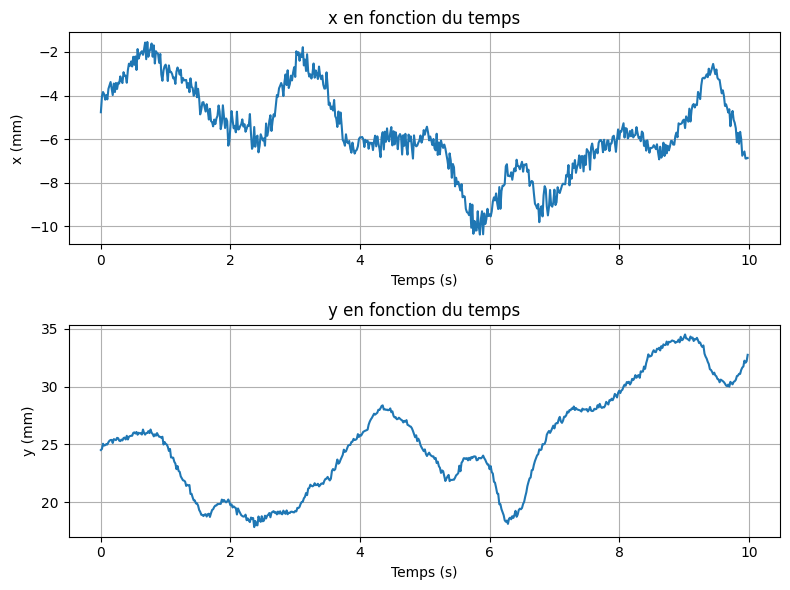

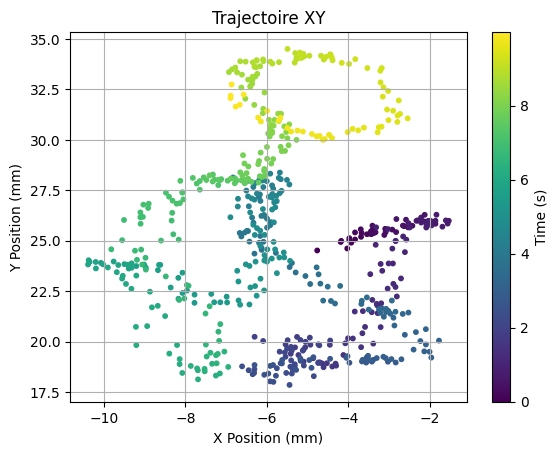

In [152]:

# ---- Plot X(t) et Y(t) ----
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(times, x_pos)
plt.xlabel("Temps (s)")
plt.ylabel("x (mm)")
plt.title("x en fonction du temps")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(times, y_pos)
plt.xlabel("Temps (s)")
plt.ylabel("y (mm)")
plt.title("y en fonction du temps")
plt.grid(True)

plt.tight_layout()
plt.show()


plt.figure()
sc = plt.scatter(x_pos, y_pos, c=times, cmap='viridis', s=10)
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.title("Trajectoire XY")
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()


## Centered

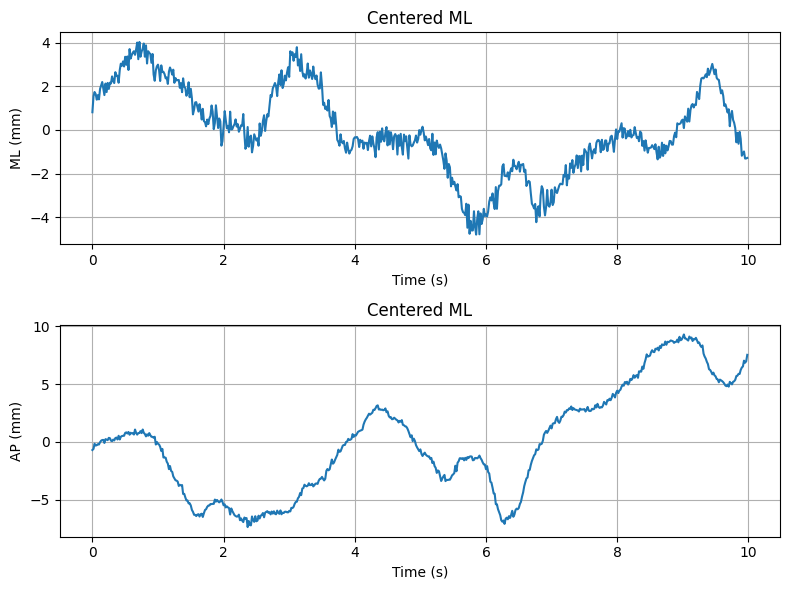

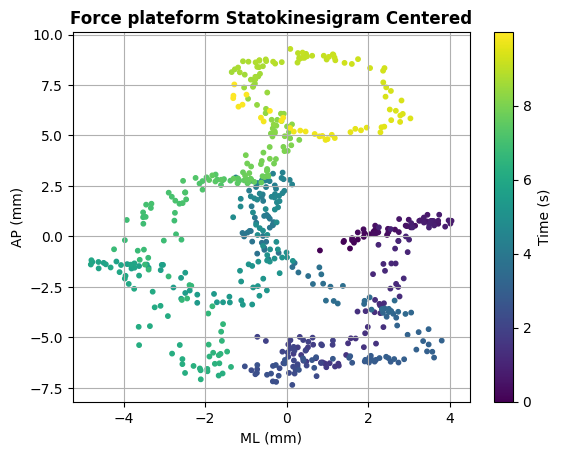

In [153]:
x_pos -= np.mean(x_pos)
y_pos -= np.mean(y_pos)

# ---- Plot X(t) et Y(t) ----
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(times, x_pos)
plt.xlabel("Time (s)")
plt.ylabel("ML (mm)")
plt.title("Centered ML")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(times, y_pos)
plt.xlabel("Time (s)")
plt.ylabel("AP (mm)")
plt.title("Centered ML")
plt.grid(True)

plt.tight_layout()
plt.show()


plt.figure()
sc = plt.scatter(x_pos, y_pos, c=times, cmap='viridis', s=10)
plt.xlabel("ML (mm)")
plt.ylabel("AP (mm)")
plt.title("Force plateform Statokinesigram Centered", fontweight='bold')
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()


## Normalization

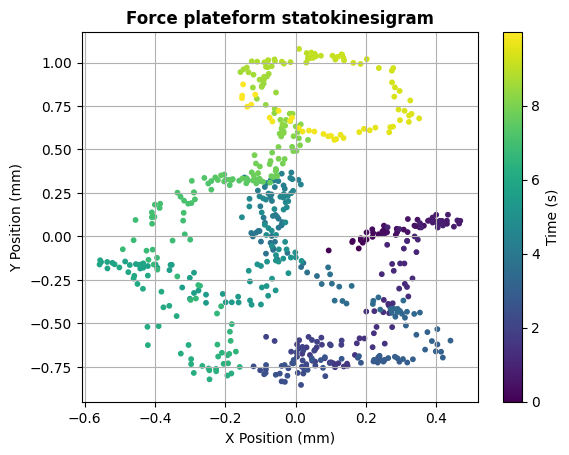

In [154]:
x = x_pos - np.mean(x_pos)
y = y_pos - np.mean(y_pos)

modulus = np.sqrt(x**2 + y**2)
angle = np.arctan2(y, x)

modulus95 = modulus[modulus <= np.percentile(modulus, 95)]
rmax = np.max(modulus95)

mod_norm = modulus / rmax
x_norm = mod_norm * np.cos(angle)
y_norm = mod_norm * np.sin(angle)

plt.figure()
sc = plt.scatter(x_norm, y_norm, c=times, cmap='viridis', s=10)
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.title("Force plateform statokinesigram", fontweight='bold')
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()

## Getting CoP variables

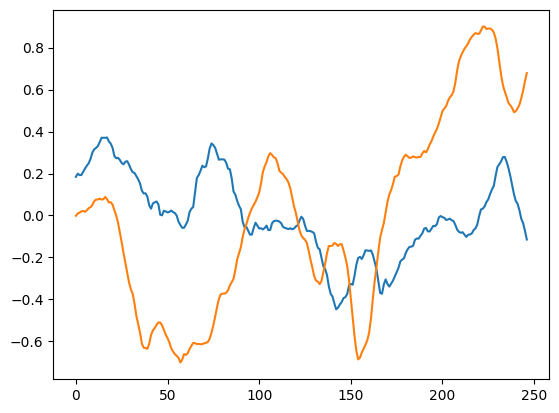

In [155]:
data = np.array([x_pos/10, y_pos/10]).T
stato = Stabilogram()
stato.from_array(array=data, original_frequency=60)

plt.plot(stato.medio_lateral)
plt.plot(stato.antero_posterior)

In [156]:
sway_density_radius = 0.3 # 3 mm
params_dic = {"sway_density_radius": sway_density_radius}
features = compute_all_features(stato, params_dic=params_dic)

C:\Users\Kelly\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 250 is greater than input length  = 247, using nperseg = 247
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


In [157]:
features

{'mean_value_ML': np.float64(4.362251300923011e-17),
 'mean_value_AP': np.float64(-1.0177044392397268e-17),
 'mean_distance_ML': np.float64(0.15687958897400722),
 'mean_distance_AP': np.float64(0.3795040644748326),
 'mean_distance_Radius': np.float64(0.4496864608255143),
 'maximal_distance_ML': np.float64(0.4475895459922262),
 'maximal_distance_AP': np.float64(0.9010480195499126),
 'maximal_distance_Radius': np.float64(0.9016402238647988),
 'rms_ML': np.float64(0.19665590342308437),
 'rms_AP': np.float64(0.45671640712022193),
 'rms_Radius': np.float64(0.4972558907483689),
 'range_ML': np.float64(0.8192364045156642),
 'range_AP': np.float64(1.6020445492005115),
 'range_ML_AND_AP': np.float64(1.6069391771452968),
 'range_ratio_ML_AND_AP': np.float64(0.511369303010018),
 'planar_deviation_ML_AND_AP': np.float64(0.4972558907483689),
 'coefficient_sway_direction_ML_AND_AP': np.float64(-0.021674423462768183),
 'confidence_ellipse_area_ML_AND_AP': np.float64(1.7249612019562597),
 'principal_s

In [158]:
def getting_descriptors(xml_file, csv_gait_file):
    
    begin_time = get_begin_time(xml_file)
    times, x_pos, y_pos = get_gait_samples(csv_gait_file)

    times = times + begin_time
    positive_time = np.where((times >= 0) & (times <= 10))
    times = times[positive_time]
    x_pos = x_pos[positive_time]
    y_pos = y_pos[positive_time]

    x_pos = x_pos - np.mean(x_pos)
    y_pos = y_pos - np.mean(y_pos)

    data = np.array([x_pos/10, y_pos/10]).T
    stato = Stabilogram()
    stato.from_array(array=data, original_frequency=60)
    sway_density_radius = 0.3 # 3 mm
    params_dic = {"sway_density_radius": sway_density_radius}
    features = compute_all_features(stato, params_dic=params_dic)
    return features

## Getting CoP Variables for every sample

In [159]:
file_list = [
    ["../data/antoine/plateforme/test1.xml", "../data/antoine/plateforme/test1/gait-line.csv"],
    ["../data/antoine/plateforme/test2.xml", "../data/antoine/plateforme/test2/gait-line.csv"],
    ["../data/antoine/plateforme/test3.xml", "../data/antoine/plateforme/test3/gait-line.csv"],
    ["../data/antoine/plateforme/test4.xml", "../data/antoine/plateforme/test4/gait-line.csv"],
    ["../data/kelly/plat.xml", "../data/kelly/gait-line.csv"]
]

features_list = []
for xml_file, gait_file in file_list:
    features = getting_descriptors(xml_file, gait_file)
    features_list.append(features)

df_features = pd.DataFrame(features_list)
df_features.to_csv("../results/platform_descriptors.csv")



C:\Users\Kelly\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 250 is greater than input length  = 248, using nperseg = 248
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
C:\Users\Kelly\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 250 is greater than input length  = 248, using nperseg = 248
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
C:\Users\Kelly\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 250 is greater than input length  = 247, using nperseg = 247
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
C:\Users\Kell

In [160]:
df_features

,mean_value_ML,mean_value_AP,mean_distance_ML,mean_distance_AP,mean_distance_Radius,maximal_distance_ML,maximal_distance_AP,maximal_distance_Radius,rms_ML,rms_AP,...,critical_time_Diffusion_ML,critical_displacement_Diffusion_ML,short_time_scaling_Diffusion_ML,long_time_scaling_Diffusion_ML,short_time_diffusion_Diffusion_AP,long_time_diffusion_Diffusion_AP,critical_time_Diffusion_AP,critical_displacement_Diffusion_AP,short_time_scaling_Diffusion_AP,long_time_scaling_Diffusion_AP
0,5.298036e-16,5.231533e-16,2.347007,2.557343,3.853823,4.896923,4.869499,5.134238,2.735368,2.915633,...,1.937276,74.388115,0.987443,-2.486786,27.545746,45965.144315,2.088651,117.067531,0.982259,-4.054813
1,-2.283254e-16,-5.379317e-16,2.273963,1.897114,3.267737,4.668582,4.443745,4.857931,2.556930,2.169159,...,1.905195,64.673233,0.980250,-1.938494,16.051054,884.458761,1.840828,52.942651,0.977880,-2.307191
2,-1.487699e-16,1.902182e-16,1.952579,1.982994,3.079828,4.741563,5.216000,6.127952,2.244178,2.337735,...,1.366794,23.250684,0.949215,-0.381827,21.130721,3961.377267,1.897971,70.927669,0.944881,-3.138871
3,1.248770e-16,-1.551726e-17,1.578559,1.966312,2.749516,3.752168,4.751354,4.772555,1.839562,2.297666,...,1.848206,40.537489,0.964889,-2.255265,21.384057,703.829288,1.743777,62.557670,0.965234,-2.176452
4,4.362251e-17,-1.017704e-17,0.156880,0.379504,0.449686,0.447590,0.901048,0.901640,0.196656,0.456716,...,0.499249,0.032845,0.819624,0.302755,0.363872,0.800580,1.373605,0.653318,0.921849,-0.320177


## Little comparison of radar based stabilogram and force platform one 

It's not supposed to be here but im guess im too lazy 

In [165]:
# df = pd.read_csv("../results/antoine/test1_position.csv")
# time_radar = df["time"].values
# x_pos_radar = df["x_pos"].values
# y_pos_radar = df["y_pos"].values

# plt.figure(figsize=(10, 6))
# plt.suptitle("Radar and Force plateform Stabilogram Centered", fontweight='bold')

# plt.subplot(2, 1, 1)
# plt.plot(time_radar, x_pos_radar, label="radar")
# plt.plot(times, x_pos, label="force platform")
# plt.xlabel("time (s)")
# plt.ylabel("ML (mm)")
# plt.title("ML axis")
# plt.legend()
# plt.grid

# plt.subplot(2, 1, 2)
# plt.plot(time_radar, y_pos_radar, label="radar")
# plt.plot(times, y_pos, label="force platform")
# plt.xlabel("time (s)")
# plt.ylabel("AP (mm)")
# plt.title("AP axis")
# plt.legend()
# plt.grid

# plt.tight_layout(pad=2)
# plt.show()

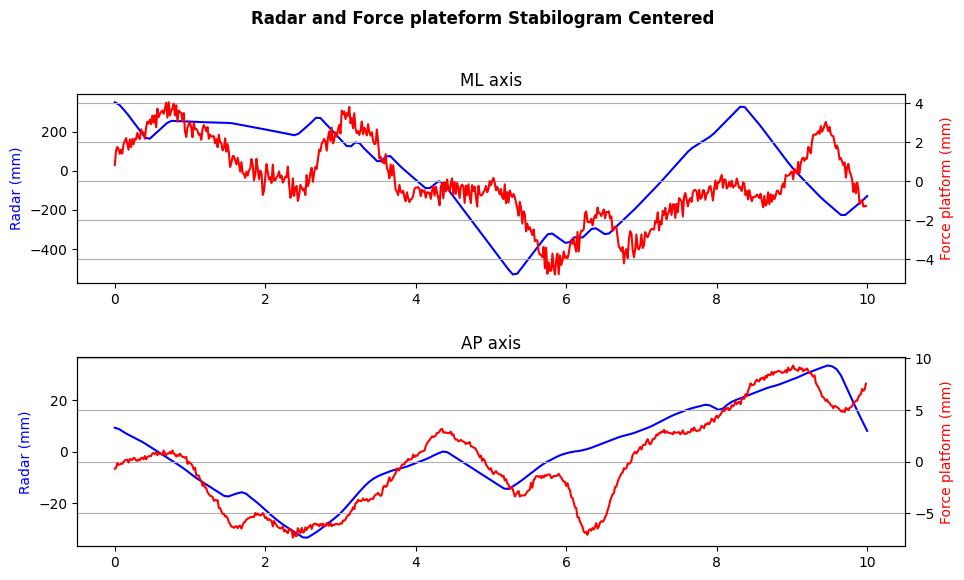

In [166]:
df = pd.read_csv("../results/kelly/position.csv")
time_radar = df["time"].values
x_pos_radar = df["x_pos"].values
y_pos_radar = df["y_pos"].values

plt.figure(figsize=(10, 6))
plt.suptitle("Radar and Force plateform Stabilogram Centered", fontweight='bold')

plt.subplot(2, 1, 1)

ax1 = plt.gca()  # axe gauche
ax1.plot(time_radar, x_pos_radar, label="radar", color='blue')
ax1.set_ylabel("Radar (mm)", color='blue')

ax2 = ax1.twinx()  # axe droit
ax2.plot(times, x_pos, label="force platform", color='red')
ax2.set_ylabel("Force platform (mm)", color='red')

plt.xlabel("time (s)")
plt.title("ML axis")
plt.grid()

plt.subplot(2, 1, 2)
ax1 = plt.gca()  # axe gauche
ax1.plot(time_radar, y_pos_radar, label="radar", color='blue')
ax1.set_ylabel("Radar (mm)", color='blue')

ax2 = ax1.twinx()  # axe droit
ax2.plot(times, y_pos, label="force platform", color='red')
ax2.set_ylabel("Force platform (mm)", color='red')

plt.xlabel("time (s)")
plt.title("AP axis")
plt.grid()

plt.tight_layout(pad=2)
plt.show()